# Metody analizy sieci złozonych

## Raport lista 1

---

### Zadanie nr 1 - zapoznanie się z podstawowymi narzędziami do analizy sieci złozonych oraz z podstawowymi miarami sieciowymi


### 1.1 Stworzenie pliku `asoiaf.csv` w oparciu o `out.asoiaf`

In [3]:
input_path = 'data/asoiaf/out.asoiaf'
output_path = 'data/asoiaf/asoiaf.csv'

with open(input_path, 'r') as infile, open(output_path, 'w') as outfile:
    for line in infile:
        if line.startswith('%'):
            continue

        parts = line.strip().split()

        if (len(parts) >= 2):
            outfile.write(f"{parts[0]},{parts[1]}\n")


### 1.2 Konfiguracja Neo4j

Wykonano następujące kroki w aplikacji Neo4j Desktop:

1. Utworzono nową lokalną bazę danych
2. Zainstalowano i włączono pluginy **APOC** i **Graph Data Science**
3. Plik `asoiaf.csv` przeniesiono do folderu `import` bazy danych

---

### 1.3 Import danych

Następnie wykonano ponizsze zapytania Cypher w aplikacji:

- zapewnienie unikalności węzłów:
```cypher
CREATE CONSTRAINT character_id IF NOT EXISTS
FOR (c:Character)
REQUIRE c.id IS UNIQUE;
```

- import węzłów i krawędzi z pliku CSV:
```cypher
LOAD CSV FROM 'file:///asoiaf.csv' AS row
WITH toInteger(row[0]) AS src, toInteger(row[1]) AS dst
MERGE (a:Character {id: src})
MERGE (b:Character {id: dst})
MERGE (a)-[:INTERACTS_WITH]->(b)
MERGE (b)-[:INTERACTS_WITH]->(a);
```

- stworzenie projekcji grafu:
```cypher
CALL gds.graph.project(
  'asoiafGraph',
  'Character',
  'INTERACTS_WITH'
)
```



### 1.4 Wizualizacja grafu

* Pełny graf:
![Pełny graf](results-ss/bloom-visualisation_0.png)

* Graf z Pagerank
![Graf z PageRank](results-ss/bloom-visualisation.png)

* Graf filtrowany (degree>12):
zastosowano równiez tutaj styl dla degree centrality
![Graf z degree>12](results-ss/bloom-visualisation_degree12.png)

### 1.5 Wierzchołki o najwyzszych wartościach zaaplikowanych centralności

Do pozyskania tych informacji wykorzystano zapytania Cypher:

* Pagerank

```cypher
CALL gds.pageRank.stream('asoiafGraph')
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).id AS node, score
ORDER BY score DESC
LIMIT 1
```

wynik:

| node | score              |
|------|--------------------|
| 60   | 14.500738434974942 |


* Degree centrality

```cypher
CALL gds.degree.stream('asoiafGraph')
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).id AS node, score
ORDER BY score DESC
LIMIT 1
```

wynik:

| node | score |
|------|-------|
| 11   | 122.0 |


Dyskusja po części 1:

- aplikacja wydaje się dosyć mało intuicyjna, wymaga trochę czasu na zapoznanie się i znalezienie potrzebych funkcji - szczególnie w zakładce Explore - według mnie wizualizacja grafu. Zakładkę Query natomiast oceniam całkiem intuicyjnie i czytelnie. Szczególny problem jak na pierwsze uzytkownie sprawiło odnalezienie niektórych funkcji związanych z analizą grafów w pluginie Graph Data Science, poniewaz nie wszystkie opcje są od razu widoczne lub wymagają wcześniejszego przygotowania projekcji grafu.
- uwazam, ze operacje wykonywaly sie szybko i płynnie - praktycznie od razu (wyjątek to zmiana layoutu na hierarchiczny - tu trzeba było chwilę poczekać)
- `force-based` layout uwidocznił skupiska/grupy węzłów oraz centralne punkty w sieci
- zmiana layoutu na `circular` pozwolila na latwiejsze zobrazowanie liczby polaczen miedzy node'ami w sposób bardziej uporządkowany, ale trudniej było w nim zauwazyć grupy w sieci:

![Graf z PageRank](results-ss/bloom-visualisation_circ.png)

## Część 2

### 4.2.1 Grafy losowe (model Erdős-Rényi)

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

a) stworzenie sieci Erdős-Rényi o N=100, p=0.05

In [14]:
network_er = nx.erdos_renyi_graph(n=100, p=0.05, seed=42)
print(f'liczba wierzchołków: {network_er.number_of_nodes()}')
print(f'liczba krawędzi: {network_er.number_of_edges()}')

liczba wierzchołków: 100
liczba krawędzi: 224


b) wylistowanie wszystkich wierzchołków i krawędzi

In [10]:
edges_er = network_er.edges
nodes_er = network_er.nodes
print(f'edges: {edges_er}')
print(f'nodes: {nodes_er}')

edges: [(0, 2), (0, 10), (0, 13), (0, 20), (0, 42), (0, 68), (0, 90), (1, 3), (1, 27), (1, 29), (2, 75), (2, 96), (3, 7), (3, 34), (3, 52), (3, 78), (4, 9), (4, 30), (4, 42), (4, 96), (5, 14), (5, 22), (5, 25), (5, 39), (5, 49), (5, 64), (6, 17), (6, 26), (6, 65), (7, 20), (7, 52), (7, 64), (8, 62), (8, 71), (8, 96), (9, 19), (9, 37), (9, 63), (10, 22), (10, 32), (10, 61), (10, 79), (10, 92), (10, 99), (11, 12), (11, 27), (12, 16), (12, 24), (12, 30), (12, 56), (12, 59), (12, 65), (12, 75), (12, 76), (12, 84), (14, 42), (14, 93), (14, 99), (15, 27), (15, 37), (15, 44), (15, 65), (15, 73), (15, 86), (15, 88), (16, 42), (16, 58), (17, 27), (17, 79), (17, 80), (18, 47), (18, 85), (19, 31), (19, 45), (19, 48), (20, 38), (20, 67), (21, 27), (21, 85), (21, 92), (22, 37), (22, 38), (22, 54), (22, 57), (22, 60), (23, 50), (24, 28), (24, 37), (24, 45), (24, 47), (24, 51), (24, 78), (24, 87), (24, 92), (24, 97), (25, 52), (25, 72), (25, 81), (27, 29), (27, 36), (27, 48), (27, 81), (28, 61), (28,

c) stopień kazdego węzła

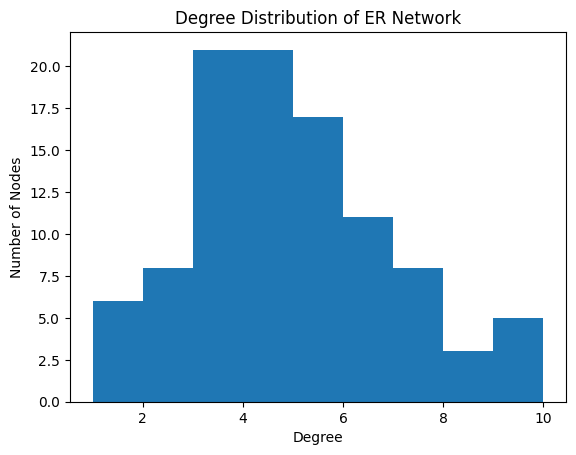

In [ ]:
degree_dict = dict(network_er.degree())

plt.hist(degree_dict.values(), bins=range(1, max(degree_dict.values()) + 1))
plt.title('Degree Distribution of ER Network')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.show()

d) Przygotuj dataframe oraz jego opis statystyczny z wykorzystaniem funkcji **describe**. DataFrame powinien zawierać metryki obliczone dla wygenerowanej sieci losowej, przy czym:

* kazdy wiersz odpowiada pojedynczemu wierzchołkowi grafu,
* indeksem ramki danych jest numer wierzchołka grafu

Nalezy uwzględnić następujące metryki:

betweenness centrality, closeness centrality, clustering coefficient, PageRank, avg. shortest path, diameter, number of connected components, network density

In [28]:
# metryki globalne:
density = nx.density(network_er)
components = list(nx.connected_components(network_er))
num_components = nx.number_connected_components(network_er)

# metryki dla kazdego wierzchołka:
betweenness = nx.betweenness_centrality(network_er)
closeness = nx.closeness_centrality(network_er)
clustering_coeff = nx.clustering(network_er)
pagerank = nx.pagerank(network_er)

# metryki te potrzebują spójnej sieci:
largest_comp = network_er.subgraph(max(components, key=len)).copy()
avg_shortest_path = nx.average_shortest_path_length(largest_comp)
diameter = nx.diameter(largest_comp)

df_er = pd.DataFrame({
    'betweenness_centrality': betweenness,
    'closeness_centrality': closeness,
    'clustering_coefficient': clustering_coeff,
    'pagerank': pagerank,
    'avg_shortest_path': avg_shortest_path,
    'diameter': diameter,
    'n_connected_components': num_components,
    'network_density': density
})
df_er


,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,avg_shortest_path,diameter,n_connected_components,network_density
0,0.057686,0.348592,0.000000,0.015786,3.149697,6,1,0.045253
1,0.005995,0.289474,0.333333,0.007274,3.149697,6,1,0.045253
2,0.006593,0.312303,0.000000,0.007057,3.149697,6,1,0.045253
3,0.027686,0.332215,0.100000,0.010870,3.149697,6,1,0.045253
4,0.009870,0.327815,0.000000,0.008646,3.149697,6,1,0.045253
...,...,...,...,...,...,...,...,...
95,0.000000,0.243842,0.000000,0.003437,3.149697,6,1,0.045253
96,0.049275,0.368030,0.000000,0.016287,3.149697,6,1,0.045253
97,0.039476,0.340206,0.000000,0.013244,3.149697,6,1,0.045253
98,0.021350,0.325658,0.000000,0.010984,3.149697,6,1,0.045253


In [29]:
df_er.describe()

,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,avg_shortest_path,diameter,n_connected_components,network_density
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.0,100.0,1.000000e+02
mean,0.021936,0.321045,0.042341,0.010000,3.149697e+00,6.0,1.0,4.525253e-02
std,0.021229,0.033182,0.095074,0.003907,1.785306e-15,0.0,0.0,1.394770e-17
min,0.000000,0.228111,0.000000,0.003369,3.149697e+00,6.0,1.0,4.525253e-02
25%,0.007198,0.303681,0.000000,0.007260,3.149697e+00,6.0,1.0,4.525253e-02
50%,0.016789,0.321429,0.000000,0.009203,3.149697e+00,6.0,1.0,4.525253e-02
75%,0.028001,0.342858,0.049603,0.012304,3.149697e+00,6.0,1.0,4.525253e-02
max,0.116356,0.412500,0.666667,0.020749,3.149697e+00,6.0,1.0,4.525253e-02


e) Ile jest komponentów (connected components) w grafie

In [30]:
print(f'Liczba komponentów: {num_components}')

Liczba komponentów: 1


f) Wizualizacja grafu w taki sposób, aby rozmiar węzłów odpowiadał mierze PageRank

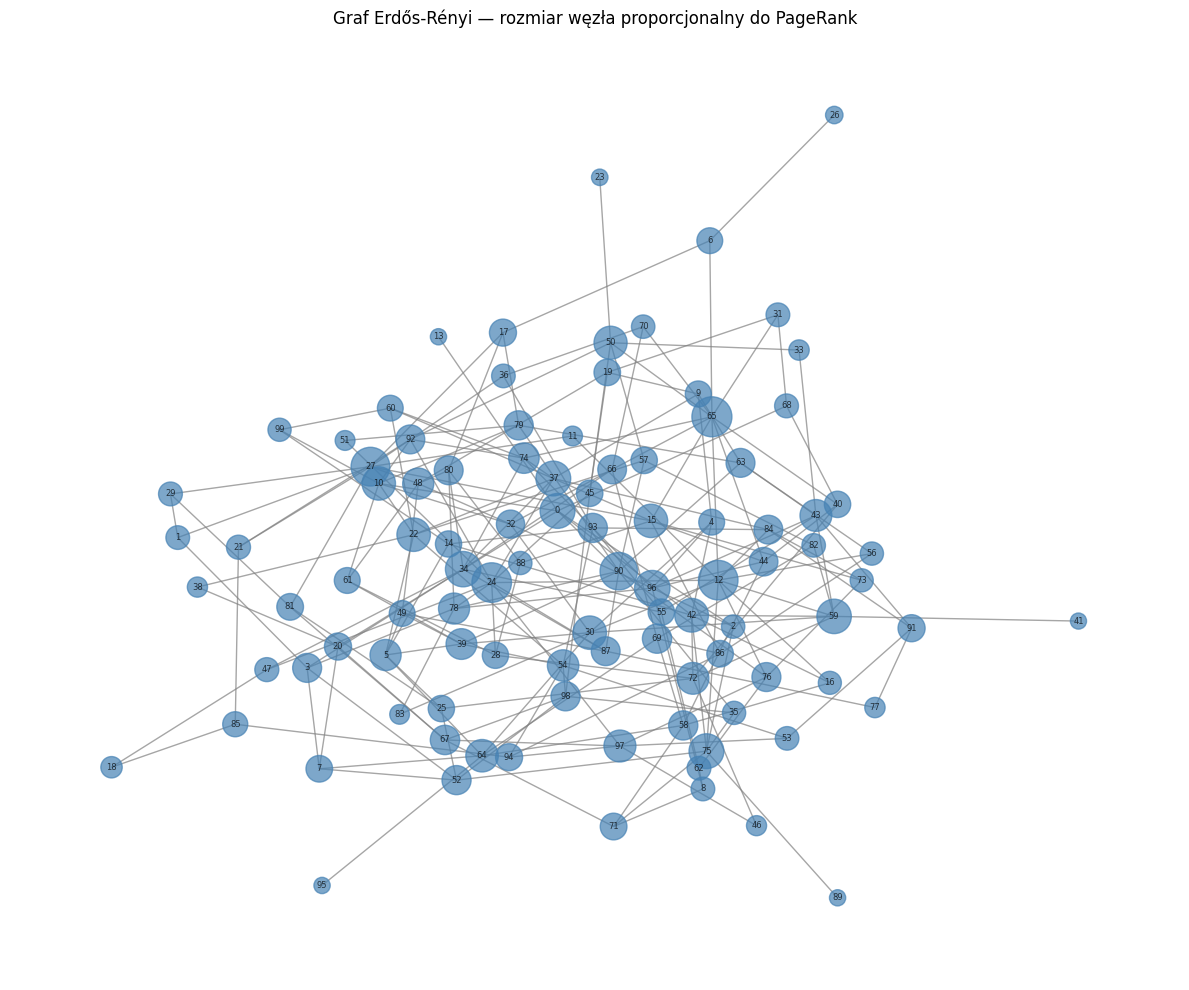

In [38]:
pagerank_values = list(pagerank.values())
node_sizes = [v * 40000 for v in pagerank_values]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(network_er, seed=42)
nx.draw_networkx(
    network_er,
    pos=pos,
    node_size=node_sizes,
    node_color='steelblue',
    edge_color='gray',
    alpha=0.7,
    with_labels=True,
    font_size=6
)
plt.title('Graf Erdős-Rényi — rozmiar węzła proporcjonalny do PageRank')
plt.axis('off')
plt.tight_layout()
plt.show()

### 4.2.2 Sieci bezskalowe (model Barabási-Albert)

a) graf wedle modelu Barabási-Albert z N=1000 i m_0 = m = 3

In [98]:
network_ba = nx.barabasi_albert_graph(n=1000, m=3, seed=42)
print(f'liczba wierzchołków: {network_ba.number_of_nodes()}')
print(f'liczba krawędzi: {network_ba.number_of_edges()}')

liczba wierzchołków: 1000
liczba krawędzi: 2991


b) Wizualizacja grafu layoutem Kamada-Kawai

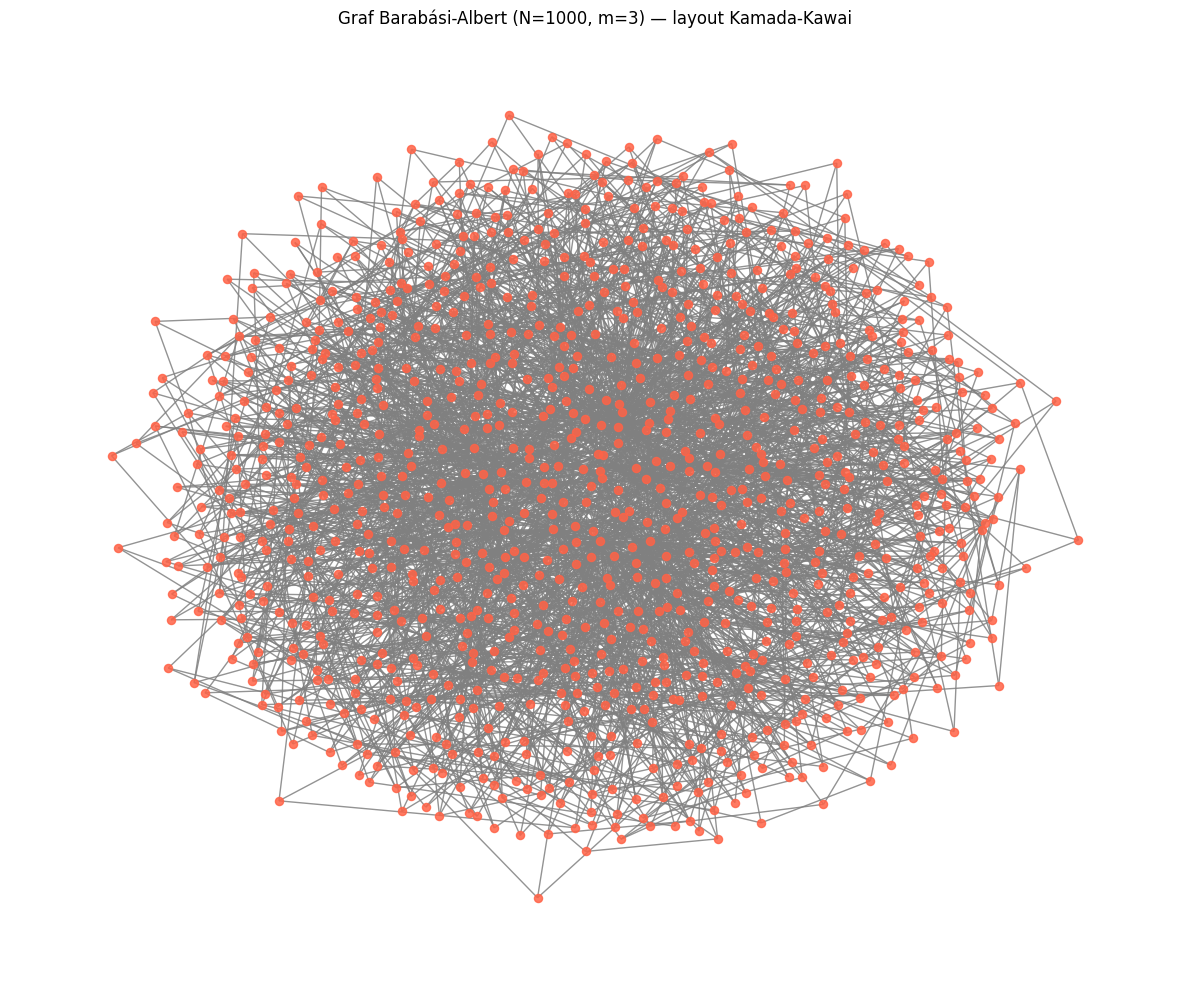

In [99]:
pos_kk = nx.kamada_kawai_layout(network_ba)

plt.figure(figsize=(12, 10))
nx.draw_networkx(
    network_ba,
    pos=pos_kk,
    node_size=34,
    node_color='tomato',
    edge_color='gray',
    alpha=0.85,
    with_labels=False
)
plt.title('Graf Barabási-Albert (N=1000, m=3) — layout Kamada-Kawai')
plt.axis('off')
plt.tight_layout()
plt.show()

c) Najbardziej centralny węzeł według miary pośrednictwa (betweenness)

In [53]:
betweenness_ba = nx.betweenness_centrality(network_ba)
node_id = max(betweenness_ba, key=betweenness_ba.get)

print(f'Wierzchołek o najwyższym betweenness: {node_id}')
print(f'betweenness: {betweenness_ba[node_id]}')
print(f'stopień wierzchołka: {network_ba.degree[node_id]}')

Wierzchołek o najwyższym betweenness: 4
betweenness: 0.15127762433284186
stopień wierzchołka: 93


d) Średnica grafu

In [50]:
diameter_ba = nx.diameter(network_ba)
print(f'Średnica grafu Barabási-Albert: {diameter_ba}')

Średnica grafu Barabási-Albert: 6


e) Róznice między grafem Barabási-Albert i Erdős-Rényi

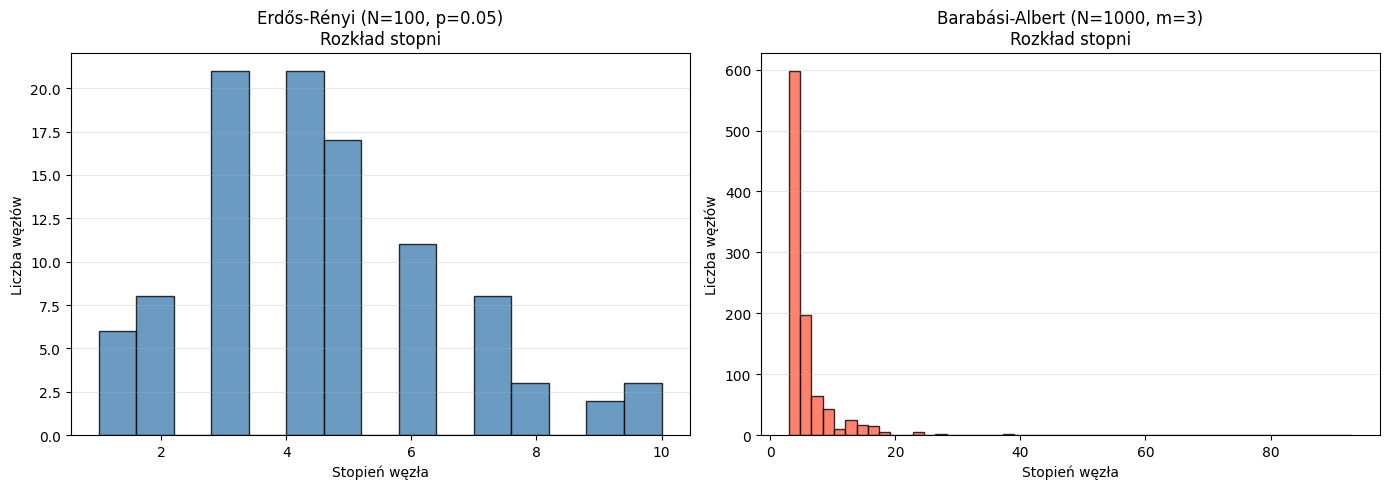

In [ ]:
# histogram stopni dla obu sieci:
degrees_ba = [d for _, d in network_ba.degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(list(dict(network_er.degree()).values()), bins=15, edgecolor='black',
             color='steelblue', alpha=0.8)
axes[0].set_title('Erdős-Rényi (N=100, p=0.05)\nRozkład stopni')
axes[0].set_xlabel('Stopień węzła')
axes[0].set_ylabel('Liczba węzłów')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(degrees_ba, bins=50, edgecolor='black',
             color='tomato', alpha=0.8)
axes[1].set_title('Barabási-Albert (N=1000, m=3)\nRozkład stopni')
axes[1].set_xlabel('Stopień węzła')
axes[1].set_ylabel('Liczba węzłów')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Rożnice między grafami Barabasi-Albert i Erdos-Renyi:

* mechanizm tworzenia krawędzi:

  a) graf Barabasi-ALbert:
    - sieć rośnie stopniowo, dodaje się nowe węzły jeden po drugim
    - każdy nowy węzeł preferencyjnie łączy się z tymi, ktorzy już mają dużo połączeń
   (analogia: im więcej ma się znajomych, tym bardziej nowi ludzie mogą 
  chcieć się z tobą zaprzyjaźnić)

  b) Erdos-Renyi:
    - krawędzie dodawane są losowo i każda para węzłow ma takie samo
    prawdopodobieństwo połączenia

* wygląd sieci:

  a) Barabasi-Albert:
    - większość węzłów ma mało połączeń, natomiast tylko kilka staje się
    bardzo silnie połączonymi hubami (węzły o duzym stopniu węzła)

  b) Erdos Renyi:
    - liczba połączeń jest czysto losowa, nie ma żadnych hubów jak w
    przypadku grafu BA

* rozkład stopni

  a) Barabasi-Albert:
    - kilka węzłów ma bardoz wysoki stopień, natomiast większość raczej
    minimalny - tworzy on rozkład potęgowy - tworząc długi ogon dla duzych stopni węzła

  b) Erdos Renyi:
    - Porównując rozkłady stopni obu sieci, mozna zauwazyc, ze dla grafu Erdős-Rényi przyjmuje on rozkład Poissona

### 4.2.3 Praca z rzeczywistymi danymi

a) Import zbioru **out.radoslaw_email_email**

In [57]:
df_email = pd.read_csv(
    'data/radoslaw_email/out.radoslaw_email_email',
    sep=' ',
    skiprows=2,
    header=None,
    usecols=[0, 1],
    names=['src', 'dst']
)

df_email.head()

,src,dst
0,1,2
1,1,3
2,1,4
3,1,5
4,1,6


stowrzenie grafu nieskierowanego

In [58]:
graph_email = nx.from_pandas_edgelist(df_email, source='src', target='dst')

b) Liczba wierzchołków i krawędzi grafu

In [59]:
print(f'Liczba wierzchołków: {graph_email.number_of_nodes()}')
print(f'Liczba krawędzi: {graph_email.number_of_edges()}')

Liczba wierzchołków: 167
Liczba krawędzi: 3251


Usunięcie wielokrotnych krawędzi i pętli

In [60]:
graph_email.remove_edges_from(nx.selfloop_edges(graph_email))
print(f'Liczba wierzchołków: {graph_email.number_of_nodes()}')
print(f'Liczba krawędzi: {graph_email.number_of_edges()}')

Liczba wierzchołków: 167
Liczba krawędzi: 3250


c) Stopnie węzłów, miary betweenness i closeness

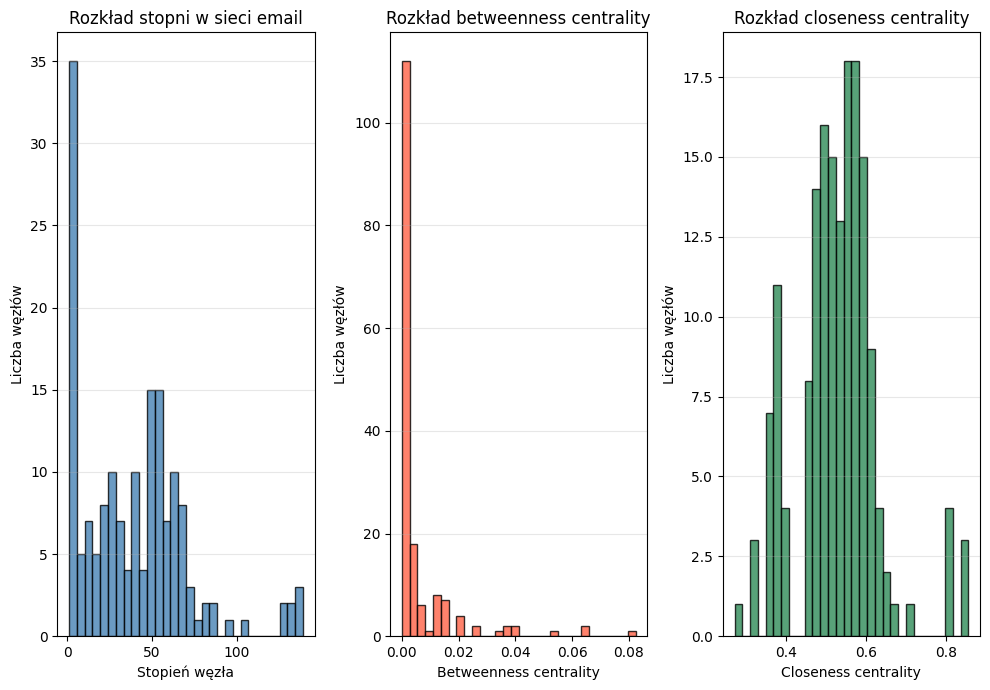

In [63]:
degrees_email = dict(graph_email.degree())
betweenness_email = nx.betweenness_centrality(graph_email)
closeness_email = nx.closeness_centrality(graph_email)

fig, ax = plt.subplots(1, 3, figsize=(10, 7))
ax[0].hist(degrees_email.values(), bins=30, edgecolor='black', color='steelblue', alpha=0.8)
ax[0].set_title('Rozkład stopni w sieci email')
ax[0].set_xlabel('Stopień węzła')
ax[0].set_ylabel('Liczba węzłów')
ax[0].grid(axis='y', alpha=0.3)
ax[1].hist(betweenness_email.values(), bins=30, edgecolor='black', color='tomato', alpha=0.8)
ax[1].set_title('Rozkład betweenness centrality')
ax[1].set_xlabel('Betweenness centrality')
ax[1].set_ylabel('Liczba węzłów')
ax[1].grid(axis='y', alpha=0.3)
ax[2].hist(closeness_email.values(), bins=30, edgecolor='black', color='seagreen', alpha=0.8)
ax[2].set_title('Rozkład closeness centrality')
ax[2].set_xlabel('Closeness centrality')
ax[2].set_ylabel('Liczba węzłów')
ax[2].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Top 10 węzłów w kazdym rankingu

In [68]:
nodes = list(graph_email.nodes())
degree_ranking = sorted(nodes, key=lambda n: degrees_email[n], reverse=True)
betweenness_ranking = sorted(nodes, key=lambda n: betweenness_email[n], reverse=True)
closeness_ranking = sorted(nodes, key=lambda n: closeness_email[n], reverse=True)

print(f'Top 10 węzłów wg stopnia: {degree_ranking[:10]}')
print(f'Top 10 węzłów wg betweenness: {betweenness_ranking[:10]}')
print(f'Top 10 węzłów wg closeness: {closeness_ranking[:10]}')

Top 10 węzłów wg stopnia: [38, 37, 45, 1, 47, 35, 113, 115, 50, 42]
Top 10 węzłów wg betweenness: [38, 37, 45, 47, 1, 68, 35, 113, 84, 80]
Top 10 węzłów wg closeness: [38, 37, 45, 1, 47, 35, 113, 115, 50, 42]


Weryfikacja korelacji rankiongów - miara Kendalla

In [71]:
from scipy.stats import kendalltau

degree_ranking_vals = [degrees_email[node] for node in nodes]
betweenness_ranking_vals = [betweenness_email[node] for node in nodes]
closeness_ranking_vals = [closeness_email[node] for node in nodes]

tau_deg_bet, p_deg_bet = kendalltau(degree_ranking_vals, betweenness_ranking_vals)
tau_deg_clo, p_deg_clo = kendalltau(degree_ranking_vals, closeness_ranking_vals)
tau_bet_clo, p_bet_clo = kendalltau(betweenness_ranking_vals, closeness_ranking_vals)

print("Korelacja Kendalla między miarami centralności:")
print(f" Degree vs Betweenness: tau = {tau_deg_bet:.3f}  (p = {p_deg_bet})")
print(f" Degree vs Closeness: tau = {tau_deg_clo:.3f}  (p = {p_deg_clo})")
print(f" Betweenness vs Closeness: tau = {tau_bet_clo:.3f}  (p = {p_bet_clo})")

Korelacja Kendalla między miarami centralności:
 Degree vs Betweenness: tau = 0.804  (p = 6.874122563216967e-51)
 Degree vs Closeness: tau = 0.951  (p = 5.182614210404855e-72)
 Betweenness vs Closeness: tau = 0.784  (p = 2.1587675953142128e-49)


Współczynnik tau bliski wartości 1 oznacza silną dodatnią korelację rankingów (te same węzły są wysoko we wszystkich miarach). Dla analizowanych miar wartości te wynoszą ponad 0.78 (a dla stopnia wierzchołka i bliskości nawet 0.95), co świadczy o wysokiej korelacji - oznacza to, ze faktycznie wierzchołchki mające wysokie wartości tych miar, są wysoko we wszsytkich rankingach. 

d) Liczba komponentów

In [76]:
components_email = list(nx.connected_components(graph_email))
print(f'Liczba komponentów w grafie email: {len(components_email)}')

isolated_email = list(nx.isolates(graph_email))
print(f'Liczba izolowanych węzłów: {len(isolated_email)}')

Liczba komponentów w grafie email: 1
Liczba izolowanych węzłów: 0


e) Średnica grafu oraz średnia długość ściezki w grafie

In [80]:
largest_component_email = graph_email.subgraph(max(components_email, key=len)).copy()

diameter_email = nx.diameter(largest_component_email)
print(f'Średnica największego komponentu: {diameter_email}')

avg_shortest_path_email = nx.average_shortest_path_length(largest_component_email)
print(f'Średnia długość najkrótszej ścieżki w największym komponencie: {avg_shortest_path_email:.3f}')

Średnica największego komponentu: 5
Średnia długość najkrótszej ścieżki w największym komponencie: 1.967


Średnia długość najkrótszej ścieki wynosi około 2, co świadczy o duzej liczbie połączeń między węzłami. Średnica grafu wynosi 5, czyli jest około 2.5 raza dłuzsza od wartości średniej dł. ściezki (według mnie nie jest to az tak duza róznica)

f) Stworzenie grafu skierowanego z importowanych danych o wadze krawędzi stanowiącej liczbę wysłanych waidomości w stosunku do wszystkich wiadmości wysłanych przez węzeł

In [92]:
total_sent = df_email.groupby('src').size().to_dict()

pair_sent = df_email.groupby(['src', 'dst']).size().reset_index(name='count')

graph_email_directed = nx.DiGraph()

for _, row in pair_sent.iterrows():
    src, dst, count = row['src'], row['dst'], row['count']
    if src != dst:
        weight = count / total_sent.get(src, 1)
        graph_email_directed.add_edge(src, dst, weight=weight)

print(f'Liczba wierzchołków (skierowany): {graph_email_directed.number_of_nodes()}')
print(f'Liczba krawędzi (skierowany): {graph_email_directed.number_of_edges()}')

Liczba wierzchołków (skierowany): 167
Liczba krawędzi (skierowany): 5783


g) Sprawdzenie, czy mozna dostać się z kazdego wierzchołka do kazdego innego.

In [94]:
is_strongly_connected = nx.is_strongly_connected(graph_email_directed)
print(f'Czy graf skierowany jest silnie spójny? {is_strongly_connected}')

strongly_connected_components = list(nx.strongly_connected_components(graph_email_directed))
print(f'Liczba silnie spójnych komponentów: {len(strongly_connected_components)}')

Czy graf skierowany jest silnie spójny? False
Liczba silnie spójnych komponentów: 42


#### Porównanie miar dotyczących ściezek w zalezności od skierowania grafu

In [107]:
largest_cc = max(nx.connected_components(graph_email), key=len)
largest_scc = max(nx.strongly_connected_components(graph_email_directed), key=len)

print("Największy komponent nieskierowany:", len(largest_cc))
print("Największy silnie spójny komponent skierowany:", len(largest_scc))

Największy komponent nieskierowany: 167
Największy silnie spójny komponent skierowany: 126


In [106]:
# metryki dotyczące ściezek, dla grafu nieskierowanego:
largest_component_email_undirected = graph_email.subgraph(max(components_email, key=len)).copy()
diameter_email_undirected = nx.diameter(largest_component_email_undirected)
print(f'Średnica największego komponentu (nieskierowany): {diameter_email_undirected}')
avg_shortest_path_email_undirected = nx.average_shortest_path_length(largest_component_email_undirected)
print(f'Średnia długość najkrótszej ścieżki w największym komponencie (nieskierowany): {avg_shortest_path_email_undirected}')

# metryki dotyczące ściezek, dla grafu skierowanego:
largest_component_email_directed = graph_email_directed.subgraph(max(strongly_connected_components, key=len)).copy()
diameter_email_directed = nx.diameter(largest_component_email_directed)
print(f'Średnica największego komponentu (skierowany): {diameter_email_directed}')
avg_shortest_path_email_directed = nx.average_shortest_path_length(largest_component_email_directed)
print(f'Średnia długość najkrótszej ścieżki w największym komponencie (skierowany): {avg_shortest_path_email_directed}')

Średnica największego komponentu (nieskierowany): 5
Średnia długość najkrótszej ścieżki w największym komponencie (nieskierowany): 1.9673905201644903
Średnica największego komponentu (skierowany): 3
Średnia długość najkrótszej ścieżki w największym komponencie (skierowany): 1.6461587301587302


Zeby dało się przejść z kazdego wierzchołka do kazdego innego, to graf musi być silnie spójny. Badany graf nie jest silnie spójny, co więcej - składa się z 42 silnie spójnych komponentów

### 5. Dyskusja po części 2

* Czytelność i intuicyjność API networkX

Uznałbym za stosunkowo czytelne i intuicyjne, znalezienie potrzebnej funkcji nie jest zbyt cięzkie, poniewaz nazwy są mocno opisowe, co ułatwia domyślenie się jak moze nazywać się potrzebna przez nas funkcja. Dokumentacja biblioteki jest tez dobrze rozwinięta

* Róznice między sieciami ER i BA

Dla 1000 wierzchołków w grafie BA cięzko było coś zobaczyć, ale po zmniejszeniu tej liczby do 100, o wiele łatwiej dało się zobaczyć róznice między grafami ER i BA. W grafie ER połączenia były bardziej równomiernie rozłozone, natomiast w BA dało się zobaczyć huby, i większą nierównomierność stopni węzłów.

* Zastosowanie współczynnika Kendalla

Dla wszystkich par analizowanych miar, współczynnik Kendalla osiągał stosunkowo wysokie wartości, co świadczy o korelacji rankingów

* Wpływ kierunkowości na średnie długości ściezek

W grafie nieskierowanym cała sieć tworzy jeden spójny komponent, dlatego metryki długości ścieżek można obliczyć dla wszystkich węzłów. Natomiast w grafie skierowanym sieć rozpada się na wiele silnie spójnych komponentów, przez co nie wszystkie węzły są wzajemnie osiągalne. W związku z tym średnią długość ścieżki oraz średnicę obliczono jedynie dla największego silnie spójnego komponentu. Oznacza to, że wartości te odnoszą się do części grafu, a nie całej sieci, co jest typową sytuacją w analizie grafów skierowanych.

Kierunkowość grafu znacząco wpływa na strukturę sieci, ponieważ ogranicza osiągalność węzłów i powoduje powstawanie wielu silnie spójnych komponentów, co utrudnia analizę globalnych metryk długości ścieżek.

